## **HandsOn3** - Multimedia/IF4021
Dimas Dharma Wicaksono - 122140215
## VIDEO PROCESSING
Assignment ini berfokus pada topik Video Processing yang menggunakan bahasa pemrograman python dengan menerapkan library - library python yang ada dan mencoba mengimplementasikan program - program untuk melakukan perintah seperti Face Detection, Landmarking dan menambahkan Overlay.
## Lampiran Link
Berikut beberapa link esensial dari project ini :
### Link Google Drive
https://drive.google.com/drive/folders/1KvQ7M9edyhvRWH2G3Yl7_cT-g9-_tcbo?usp=sharing 
### Link Kutipan AI
https://chat.qwen.ai/s/9d0c71ca-2dad-4363-8fe6-8043f01d9810?fev=0.0.93
### Link Github
https://github.com/HYPExREAL/multimedia_itera_122140215

## **Soal 1**

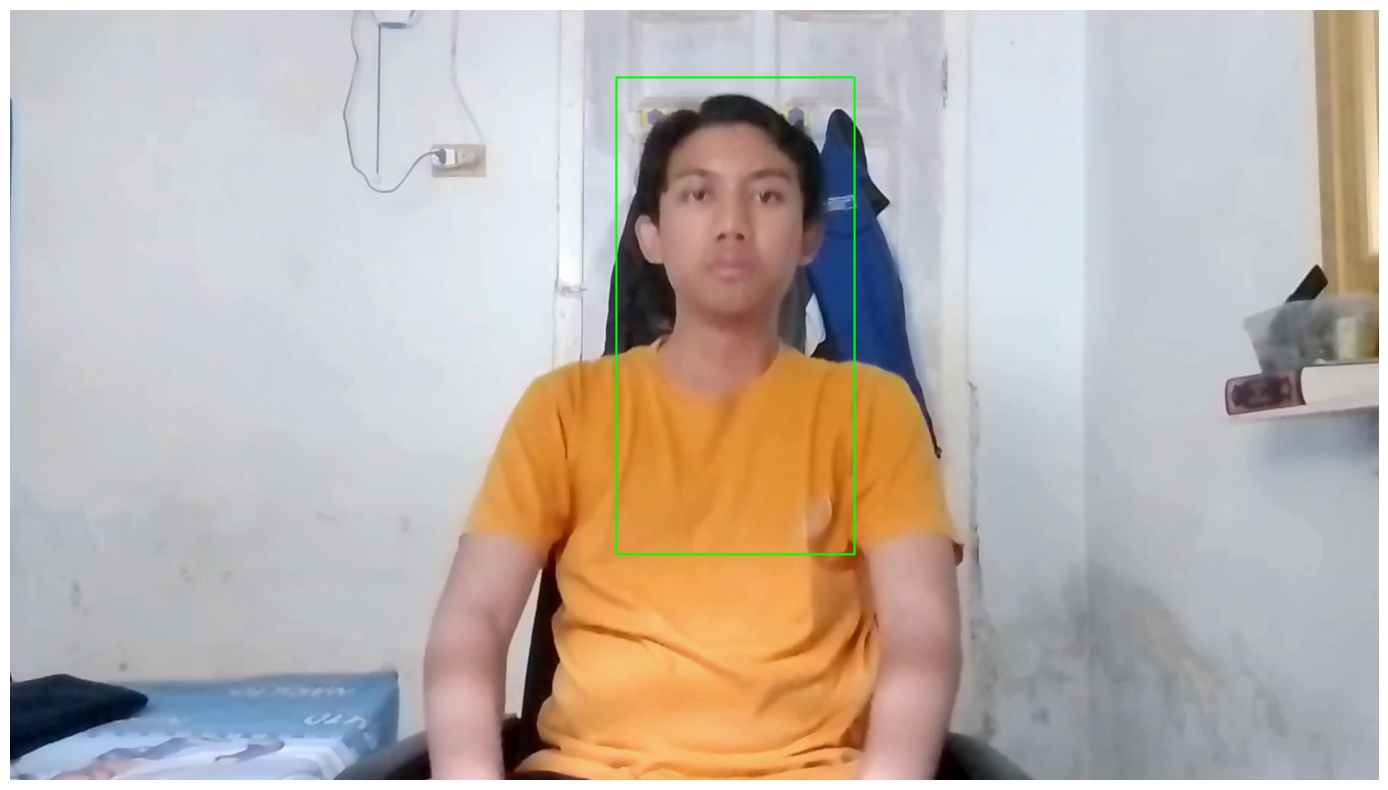

In [6]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

# Path ke video
video_path = 'MM.mp4'

# Buka video
cap = cv2.VideoCapture(video_path)

# Set resolusi output video
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)

success, frame = cap.read()
if not success:
    print("Gagal membaca frame.")
    exit()

# Resize frame jika ukurannya tidak sesuai
frame = cv2.resize(frame, (1920, 1080))

# Konversi ke RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Inisialisasi MediaPipe Face Detection
mp_face_detection = mp.solutions.face_detection
face_detection = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5)

# Deteksi wajah
results = face_detection.process(frame_rgb)
if results.detections:
    for detection in results.detections:
        bboxC = detection.location_data.relative_bounding_box
        ih, iw, _ = frame.shape
        x, y, w, h = int(bboxC.xmin * iw), int(bboxC.ymin * ih), int(bboxC.width * iw), int(bboxC.height * ih)
        
        # Sesuaikan ROI untuk area bahu hingga dada
        new_h = int(h * 3)
        new_y = max(0, y - int(h * 0.5))
        
        # Perbesar bounding box sebesar 150%
        scale_factor = 1.5
        new_w = int(w * scale_factor)
        new_x = max(0, x - int((new_w - w) / 2))
        
        # Validasi koordinat
        new_x = max(0, new_x)
        new_y = max(0, new_y)
        new_x_end = min(iw, new_x + new_w)
        new_y_end = min(ih, new_y + new_h)
        
        # Gambar bounding box
        cv2.rectangle(frame, (new_x, new_y), (new_x_end, new_y_end), (0, 255, 0), 2)

# Menyimpan Hasil
output_path = 'result.jpg'
cv2.imwrite(output_path, frame)

# Menampilkan hasil
plt.figure(figsize=(20,10))
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.imshow(frame_rgb)
plt.axis('off')
plt.show()

# Tampilkan hasil dalam ukuran penuh
cv2.namedWindow('Bounding Box', cv2.WINDOW_NORMAL)
cv2.resizeWindow('Bounding Box', 1920, 1080)
cv2.imshow('Bounding Box', frame)
cv2.waitKey(0)
cv2.destroyAllWindows()
cap.release()

Program ini digunakan untuk melakukan deteksi wajah dan memberikan bounding box untuk area wajah hingga bahu dan dada. 

## **Soal 2**

In [ ]:
import cv2
import mediapipe as mp

# Path ke video
video_path = 'MM.mp4'
output_path = 'facial_landmark.mp4'

# Buka video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Inisialisasi MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh()

while True:
    success, frame = cap.read()
    if not success:
        break
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(frame_rgb)
    
    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            ih, iw, _ = frame.shape
            
            # Ambil koordinat landmark
            left_eye = (int(face_landmarks.landmark[33].x * iw), int(face_landmarks.landmark[33].y * ih))
            right_eye = (int(face_landmarks.landmark[263].x * iw), int(face_landmarks.landmark[263].y * ih))
            nose = (int(face_landmarks.landmark[1].x * iw), int(face_landmarks.landmark[1].y * ih))
            mouth = (int(face_landmarks.landmark[13].x * iw), int(face_landmarks.landmark[13].y * ih))
            
            # Gambar bounding box dan label
            cv2.rectangle(frame, (left_eye[0] - 20, left_eye[1] - 20), (left_eye[0] + 20, left_eye[1] + 20), (255, 0, 0), 2)
            cv2.putText(frame, "Left Eye", (left_eye[0] + 10, left_eye[1]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
            
            cv2.rectangle(frame, (right_eye[0] - 20, right_eye[1] - 20), (right_eye[0] + 20, right_eye[1] + 20), (0, 255, 0), 2)
            cv2.putText(frame, "Right Eye", (right_eye[0] + 10, right_eye[1]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
            
            cv2.rectangle(frame, (nose[0] - 20, nose[1] - 20), (nose[0] + 20, nose[1] + 20), (0, 0, 255), 2)
            cv2.putText(frame, "Nose", (nose[0] + 10, nose[1]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
            
            cv2.rectangle(frame, (mouth[0] - 20, mouth[1] - 20), (mouth[0] + 20, mouth[1] + 20), (255, 255, 0), 2)
            cv2.putText(frame, "Mouth", (mouth[0] + 10, mouth[1]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
            
            # Beri tanda titik di tengah bola mata
            cv2.circle(frame, left_eye, 2, (255, 0, 0), -1)
            cv2.circle(frame, right_eye, 2, (0, 255, 0), -1)
    
    # Simpan frame ke video output
    out.write(frame)

cap.release()
out.release()
cv2.destroyAllWindows()

Program ini digunakan untuk memberikan landmark yang berbentuk seperti bounding box di area yang diinginkan. Pada umunya wajah manusia memiliki indeks atau koordinat tertentu dari face mash yang bisa digunakan sebagai acuan untuk landmarking yaitu mata kiri = 33, mata kanan = 263, hidung = 1, dan mulut = 13. *(Hasil Video dilampirkan di Google Drive)*

## **Soal 3**

In [ ]:
import cv2
import mediapipe as mp
import numpy as np

# Path ke video dan gambar overlay
video_path = 'MM.mp4'
overlay_path = 'obito_mask.png'
output_path = 'tracking_wajah.mp4'

# Load overlay image
overlay = cv2.imread(overlay_path, cv2.IMREAD_UNCHANGED)
overlay_height, overlay_width = overlay.shape[:2]

# Buka video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Inisialisasi MediaPipe Face Detection
mp_face_detection = mp.solutions.face_detection
face_detection = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5)

frame_count = 0
skip_frames = 30  # Deteksi setiap 30 frame

while True:
    success, frame = cap.read()
    if not success:
        break
    
    frame_count += 1
    if frame_count % skip_frames != 0:
        continue
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_detection.process(frame_rgb)
    
    if results.detections:
        for detection in results.detections:
            bboxC = detection.location_data.relative_bounding_box
            ih, iw, _ = frame.shape
            x, y, w, h = int(bboxC.xmin * iw), int(bboxC.ymin * ih), int(bboxC.width * iw), int(bboxC.height * ih)
            
            # Menyesuaikan ukuran overlay
            scale_w = 1.5  
            scale_h = 1.8
            
            # Menghitung dimensi baru
            new_w = int(w * scale_w)
            new_h = int(h * scale_h)
            
            # Menyesuaikan posisi overlay
            new_x = max(0, x - (new_w - w) // 2)
            new_y = max(0, y - (new_h - h) // 2)
            
            # Memastikan overlay tidak keluar dari batas frame
            if new_x + new_w > iw:
                new_w = iw - new_x
            if new_y + new_h > ih:
                new_h = ih - new_y
            
            # Merubah ukuran overlay
            resized_overlay = cv2.resize(overlay, (new_w, new_h))
            alpha_mask = resized_overlay[:, :, 3] / 255.0
            inverse_alpha_mask = 1.0 - alpha_mask
            
            try:
                for c in range(3):
                    frame[new_y:new_y+new_h, new_x:new_x+new_w, c] = (
                        alpha_mask * resized_overlay[:, :, c] +
                        inverse_alpha_mask * frame[new_y:new_y+new_h, new_x:new_x+new_w, c]
                    )
            except ValueError:
                continue
    
    # Simpan frame ke video output
    out.write(frame)

cap.release()
out.release()
cv2.destroyAllWindows()

Pada program ini kita melakukan face detection yang mana nantinya kita bisa memberikan overlay atau semacam filter ke area wajah. Di sini dilakukan beberapa penyesuaian sehingga overlay atau filter yang akan dimasukkan bisa sesuai ukurannya. *(Hasil Video dilampirkan di Google Drive)*

## **Soal 4**

In [1]:
import cv2
import mediapipe as mp

# Path ke video
video_path = 'MM.mp4'
output_path = 'pose_landmark.mp4'

# Buka video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Inisialisasi MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

while True:
    success, frame = cap.read()
    if not success:
        break
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = pose.process(frame_rgb)
    
    if results.pose_landmarks:
        ih, iw, _ = frame.shape
        
        # Ambil koordinat landmark
        left_shoulder = (int(results.pose_landmarks.landmark[11].x * iw), int(results.pose_landmarks.landmark[11].y * ih))
        right_shoulder = (int(results.pose_landmarks.landmark[12].x * iw), int(results.pose_landmarks.landmark[12].y * ih))
        mid_hip = (int(results.pose_landmarks.landmark[24].x * iw), int(results.pose_landmarks.landmark[24].y * ih))
        
        # Gambarkan garis
        cv2.line(frame, left_shoulder, right_shoulder, (0, 255, 0), 2)
        cv2.line(frame, left_shoulder, mid_hip, (0, 255, 0), 2)
        cv2.line(frame, right_shoulder, mid_hip, (0, 255, 0), 2)
    
    # Simpan frame ke video output
    out.write(frame)

cap.release()
out.release()
cv2.destroyAllWindows()

Pada program ini melakukan pose landmarking untuk tiga bagian tubuh yaitu bahu kiri, bahu kanan, dan pinggang tengah. Masing - masing bagian tubuh memiliki koordinat tersendiri yang bisa digunakan sebagai acuan landmarking.*(Hasil Video dilampirkan di Google Drive)*